# Generating sounds using Non-Parametric Sampling
## EEC289A

In [ ]:
!curl -L -o /content/urbansound8k.zip https://www.kaggle.com/api/v1/datasets/download/chrisfilo/urbansound8k

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 5747M  100 5747M    0     0  21.7M      0  0:04:23  0:04:23 --:--:-- 22.2M


In [1]:
!curl -L -o /content/esc50.zip https://github.com/karoldvl/ESC-50/archive/master.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
curl: (23) Failure writing output to destination


In [2]:
# Imports
import os
from pathlib import Path
import random
import time

import numpy as np
from PIL import Image
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import torchvision
import torchvision.transforms as T

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import random
import librosa
import soundfile as sf
import torch
from pathlib import Path
from IPython.display import display, Audio, HTML


def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [3]:
from pathlib import Path
import zipfile

# 1. Update directory and zip names
URBAN_AUDIO_DIR = Path("/content/urbanaudio")
URBAN_AUDIO_DIR.mkdir(parents=True, exist_ok=True)
ZIP_NAME = "urbansound8k.zip"
ZIP_PATH = Path(f"/content/{ZIP_NAME}")

def list_audio_files(audio_dir: Path):
    # Common audio extensions for UrbanSound8K (mostly .wav)
    exts = (".wav", ".mp3", ".ogg", ".flac")
    return [p for p in sorted(audio_dir.iterdir()) if p.is_file() and p.suffix.lower() in exts]

audio_files = list_audio_files(URBAN_AUDIO_DIR)

# If the folder is empty, extract from the zip archive.
if len(audio_files) == 0:
    if not ZIP_PATH.exists():
        raise FileNotFoundError(
            f"No audio files found in {URBAN_AUDIO_DIR}.\n"
            f"Please upload '{ZIP_NAME}' to /content/ and re-run this cell."
        )

    # Allowed audio extensions
    exts = {".wav", ".mp3", ".ogg", ".flac", ".csv"}
    counts = {}

    print(f"Extracting audio from {ZIP_NAME}...")

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        for info in z.infolist():
            if info.is_dir():
                continue

            name = info.filename
            # Ignore macOS metadata and hidden files
            if "__MACOSX" in name or name.startswith("._"):
                continue

            suf = Path(name).suffix.lower()
            if suf not in exts:
                continue

            # Flatten the structure (get just the filename)
            base = Path(name).name
            counts.setdefault(base, 0)
            out = URBAN_AUDIO_DIR / base

            # Handle duplicate filenames across different 'folds'
            if counts[base] > 0:
                out = URBAN_AUDIO_DIR / f"{Path(base).stem}_{counts[base]}{suf}"

            counts[base] += 1

            with z.open(info) as src, open(out, "wb") as dst:
                dst.write(src.read())

    audio_files = list_audio_files(URBAN_AUDIO_DIR)

print(f"Total audio files found: {len(audio_files)}")
# Show a preview of the first 10 files
for p in audio_files[:10]:
    print(" -", p.name)

if len(audio_files) == 0:
    raise RuntimeError(f"{ZIP_NAME} contained no valid audio files.")

PermissionError: [Errno 13] Permission denied: '/content'

In [ ]:
from pathlib import Path
import zipfile

# 1. Update directory and zip names
ESC_AUDIO_DIR = Path("/content/escaudio")
ESC_AUDIO_DIR.mkdir(parents=True, exist_ok=True)
ZIP_NAME = "esc50.zip"
ZIP_PATH = Path(f"/content/{ZIP_NAME}")

def list_audio_files(audio_dir: Path):
    # Common audio extensions for UrbanSound8K (mostly .wav)
    exts = (".wav", ".mp3", ".ogg", ".flac")
    return [p for p in sorted(audio_dir.iterdir()) if p.is_file() and p.suffix.lower() in exts]

audio_files = list_audio_files(ESC_AUDIO_DIR)

# If the folder is empty, extract from the zip archive.
if len(audio_files) == 0:
    if not ZIP_PATH.exists():
        raise FileNotFoundError(
            f"No audio files found in {ESC_AUDIO_DIR}.\n"
            f"Please upload '{ZIP_NAME}' to /content/ and re-run this cell."
        )

    # Allowed audio extensions
    exts = {".wav", ".mp3", ".ogg", ".flac", ".csv"}
    counts = {}

    print(f"Extracting audio from {ZIP_NAME}...")

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        for info in z.infolist():
            if info.is_dir():
                continue

            name = info.filename
            # Ignore macOS metadata and hidden files
            if "__MACOSX" in name or name.startswith("._"):
                continue

            suf = Path(name).suffix.lower()
            if suf not in exts:
                continue

            # Flatten the structure (get just the filename)
            base = Path(name).name
            counts.setdefault(base, 0)
            out = ESC_AUDIO_DIR / base

            # Handle duplicate filenames across different 'folds'
            if counts[base] > 0:
                out = ESC_AUDIO_DIR / f"{Path(base).stem}_{counts[base]}{suf}"

            counts[base] += 1

            with z.open(info) as src, open(out, "wb") as dst:
                dst.write(src.read())

    audio_files = list_audio_files(ESC_AUDIO_DIR)

print(f"Total audio files found: {len(audio_files)}")
# Show a preview of the first 10 files
for p in audio_files[:10]:
    print(" -", p.name)

if len(audio_files) == 0:
    raise RuntimeError(f"{ZIP_NAME} contained no valid audio files.")

Extracting audio from esc50.zip...
Total audio files found: 2000
 - 1-100032-A-0.wav
 - 1-100038-A-14.wav
 - 1-100210-A-36.wav
 - 1-100210-B-36.wav
 - 1-101296-A-19.wav
 - 1-101296-B-19.wav
 - 1-101336-A-30.wav
 - 1-101404-A-34.wav
 - 1-103298-A-9.wav
 - 1-103995-A-30.wav


In [ ]:
AUDIO_DIR = Path('/content/audio')
urban_df = None
if os.path.exists(URBAN_AUDIO_DIR / 'UrbanSound8K.csv'):
    urban_df = pd.read_csv(URBAN_AUDIO_DIR / 'UrbanSound8K.csv')
    urban_df['slice_file_name'] = URBAN_AUDIO_DIR / urban_df['slice_file_name']
esc_df = None
if os.path.exists(ESC_AUDIO_DIR / 'esc50.csv'):
    esc_df = pd.read_csv(ESC_AUDIO_DIR / 'esc50.csv')
    esc_df['class'] = esc_df['category']
    esc_df['slice_file_name'] = ESC_AUDIO_DIR / esc_df['filename']
df = pd.concat(list(filter(lambda x: x is not None, [urban_df, esc_df])))
df

,slice_file_name,fsID,start,end,salience,fold,classID,class,filename,target,category,esc10,src_file,take
0,/content/urbanaudio/100032-3-0-0.wav,100032.0,0.0,0.317551,1.0,5,3.0,dog_bark,NaN,NaN,NaN,NaN,NaN,NaN
1,/content/urbanaudio/100263-2-0-117.wav,100263.0,58.5,62.500000,1.0,5,2.0,children_playing,NaN,NaN,NaN,NaN,NaN,NaN
2,/content/urbanaudio/100263-2-0-121.wav,100263.0,60.5,64.500000,1.0,5,2.0,children_playing,NaN,NaN,NaN,NaN,NaN,NaN
3,/content/urbanaudio/100263-2-0-126.wav,100263.0,63.0,67.000000,1.0,5,2.0,children_playing,NaN,NaN,NaN,NaN,NaN,NaN
4,/content/urbanaudio/100263-2-0-137.wav,100263.0,68.5,72.500000,1.0,5,2.0,children_playing,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,/content/escaudio/5-263831-B-6.wav,NaN,NaN,NaN,NaN,5,NaN,hen,5-263831-B-6.wav,6.0,hen,False,263831.0,B
1996,/content/escaudio/5-263902-A-36.wav,NaN,NaN,NaN,NaN,5,NaN,vacuum_cleaner,5-263902-A-36.wav,36.0,vacuum_cleaner,False,263902.0,A
1997,/content/escaudio/5-51149-A-25.wav,NaN,NaN,NaN,NaN,5,NaN,footsteps,5-51149-A-25.wav,25.0,footsteps,False,51149.0,A
1998,/content/escaudio/5-61635-A-8.wav,NaN,NaN,NaN,NaN,5,NaN,sheep,5-61635-A-8.wav,8.0,sheep,False,61635.0,A


In [ ]:
import librosa
import torch
import numpy as np
from pathlib import Path

def load_audio_as_mfcc(
    path: Path,
    n_mfcc: int = 40,
    sr: int = 22050,
    duration: float = 4.0,
    include_dynamics: bool = False
):
    """
    Loads audio, pads/crops to a fixed duration, and returns an MFCC tensor.
    If include_dynamics is True, stacks velocity (delta) and acceleration (delta-delta)
    along the feature axis.

    Result shape:
      - (1, n_mfcc * 3, time_steps) if include_dynamics=True
      - (1, n_mfcc, time_steps) if include_dynamics=False
    """
    # Load audio (force consistent sample rate)
    y, _ = librosa.load(path, sr=sr, duration=duration)

    # Ensure consistent length (padding if audio is shorter than 4s)
    target_len = int(sr * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    # Generate static MFCC
    # n_mfcc acts like the 'Height' of our image
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    # Calculate and stack dynamic features if requested
    if include_dynamics:
        # Compute first-order differences (velocity)
        delta_mfcc = librosa.feature.delta(mfcc)
        # Compute second-order differences (acceleration)
        delta2_mfcc = librosa.feature.delta(mfcc, order=2)

        # Stack vertically: the new "image" is 3 times as tall
        mfcc = np.vstack([mfcc, delta_mfcc, delta2_mfcc])

    # Standardize/Normalize (Optional but recommended for Neural Nets)
    mfcc = (mfcc - np.mean(mfcc)) / (np.std(mfcc) + 1e-6)

    # Convert to Tensor and add Channel dimension: (1, n_features, T)
    x = torch.from_numpy(mfcc).float().unsqueeze(0)
    return x

In [ ]:
def extract_patches_from_mfcc(mfcc: torch.Tensor, window_width: int, max_patches: int | None = None, device: torch.device = "cpu"):
    """
    mfcc: (1, n_mfcc, T) -> patches: (N, 1, n_mfcc, window_width).
    Treats the MFCC as an image and slices it along the time axis.
    """
    assert mfcc.ndim == 3  # (C, H, W)
    C, n_mfcc, T = mfcc.shape

    # We want the window to cover the FULL height (n_mfcc)
    # but only a slice of the width (time)
    kernel_size = (n_mfcc, window_width)
    stride = (n_mfcc, 1) # use window_width // 2 instead of 1 if 50% overlap is common in audioension: patches_flat[:, 0, mask] instead of patches_flat[:, mask]. This was causing incorrect distance calculatio

    unfold = torch.nn.Unfold(kernel_size=kernel_size, stride=stride)

    # mfcc.unsqueeze(0) adds the Batch dim for Unfold: (1, 1, n_mfcc, T)
    patches = unfold(mfcc.unsqueeze(0))

    # Reshape to (N, C, H, W) -> (N, 1, n_mfcc, window_width)
    patches = patches.transpose(1, 2).reshape(-1, C, n_mfcc, window_width)

    if max_patches is not None and patches.shape[0] > max_patches:
        idx = torch.randperm(patches.shape[0])[:max_patches]
        patches = patches[idx]

    return patches.to(device)

In [ ]:
def compute_audio_frontier(known: torch.Tensor, valid: torch.Tensor) -> torch.Tensor:
    """
    known, valid: (H, W) bool where H=MFCC_bins, W=Time
    frontier: unknown & valid & adjacent-to-known (strictly in time)
    """
    assert known.shape == valid.shape
    H, W = known.shape
    known_f = known.float().view(1, 1, H, W)

    # We use a 1x3 kernel to look only at temporal neighbors (Left and Right)
    # Kernel shape: (out_channels, in_channels, height, width)
    # We set height to 1 because we don't care about vertical (frequency) neighbors
    k = torch.tensor([[[[1, 0, 1]]]], device=known.device).float()

    # Count known neighbors along the time axis
    # Padding=(0, 1) pads only the width (time) dimension
    nb = F.conv2d(known_f, k, padding=(0, 1)).view(H, W)

    # Frontier = unknown frames that are valid and have a known neighbor in time
    frontier = (~known) & valid & (nb > 0)

    return frontier

In [ ]:
def choose_seed_patch_index(patches: torch.Tensor, seed_fg_min: int = 0) -> int:
    """Works for audio too: sums magnitude over (C, F, T) dimensions."""
    if seed_fg_min > 0:
        # Sum over all dims except the batch (N)
        fg = patches.abs().sum(dim=[1, 2, 3])
        valid_indices = torch.nonzero(fg >= seed_fg_min).flatten()
        if valid_indices.numel() > 0:
            chosen = valid_indices[random.randint(0, valid_indices.shape[0] - 1)].item()
            return chosen
    return random.randint(0, patches.shape[0] - 1)

def choose_frontier_frame(frontier: torch.Tensor, known: torch.Tensor, window_t: int) -> int:
    """
    Finds the time-index (x) on the frontier with the most known temporal neighbors.
    It there is a tie, pick randomly.
    frontier/known: (Time,) bool
    """
    if not frontier.any(): return None
    
    # 1. Prepare the 1D kernel (Size: Out_channels, In_channels, Width)
    # A window of 'ones' counts how many neighbors are 'True' (1.0)
    kernel = torch.ones((1, 1, window_t), device=known.device)
    known_f = known.float().view(1, 1, -1)

    pad = window_t // 2
    nb = F.conv1d(known_f, kernel, padding="same").view(-1)
    frontier_counts = torch.where(frontier, nb, -1.0)

    max_val = torch.max(frontier_counts)
    candidate_indices = torch.where(frontier_counts == max_val)[0]

    choice = torch.randint(0, len(candidate_indices), (1,)).item()
    return int(candidate_indices[choice])

def sample_from_candidates(
    cand_idx: torch.Tensor,   # (M,)
    dist: torch.Tensor,       # (N,)
    dmin: torch.Tensor,       # scalar
    weighted: bool = True,
    h_mult: float = 0.3,
) -> int:
    if weighted:
        cand_dists = dist[cand_idx]
        probs = torch.exp(-(cand_dists - dmin) / (h_mult * dmin + 1e-6))
        idx = torch.multinomial(probs, num_samples=1).item()
        chosen_idx = cand_idx[idx].item()
    else:
        # Uniform random selection
        random_pos = torch.randint(0, len(cand_idx), (1,)).item()
        chosen_idx = cand_idx[random_pos].item()
    return int(chosen_idx)

def masked_ssd(tgt_patch: torch.Tensor, patches_flat: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """
    tgt_patch: (1, F, T)
    patches_flat: (N, 1, F*T)
    mask: (F*T) bool
    """
    # Flatten target and compare only at masked (known) positions
    tgt_flat = tgt_patch.reshape(1, -1) # (1, F*T)
    # SSD over the known spectral-temporal bins
    diff = (patches_flat[:, mask] - tgt_flat[:, mask]) #sub target from all patches
    return diff.square().sum(dim=-1) #return squared diff

In [ ]:
def synthesize_audio_mfcc(
    patches: torch.Tensor,
    out_time_steps: int,
    eps: float = 0.1,
    seed_fg_min: int = 0,
    weighted: bool = True,
    h_mult: float = 0.3
):
    N, C, F_bins, W_t = patches.shape
    pad = W_t // 2

    patches_flat = patches.reshape(N, C, -1)
    center_frames = patches[:, :, :, pad]

    out = torch.zeros((C, F_bins, out_time_steps + 2 * pad), device=patches.device)
    known = torch.zeros(out_time_steps + 2 * pad, dtype=torch.bool, device=patches.device)
    valid = torch.zeros_like(known)
    valid[pad : pad + out_time_steps] = True

    # NEW: History array shape is (Length, 2) to store (patch_idx, frame_within_patch)
    chosen_patch_history = torch.full((out_time_steps + 2 * pad, 2), -1, dtype=torch.long)

    # 1. Seed
    seed_idx = choose_seed_patch_index(patches, seed_fg_min)
    cx = pad + out_time_steps // 2

    # Place the WHOLE patch for the seed
    out[:, :, cx - pad : cx + pad + 1] = patches[seed_idx][0]
    known[cx - pad : cx + pad + 1] = True

    # FIX: Record ALL frames placed by the seed to eliminate the -1s
    for i in range(W_t):
        chosen_patch_history[cx - pad + i, 0] = seed_idx
        chosen_patch_history[cx - pad + i, 1] = i

    pbar = tqdm(total=out_time_steps)
    pbar.update(known[valid].sum().item())

    while known[valid].sum() < out_time_steps:
        kernel_adj = torch.tensor([1, 0, 1], dtype=torch.float32, device=patches.device).view(1, 1, 3)
        nb_adj = F.conv1d(known.float().view(1, 1, -1), kernel_adj, padding=1).view(-1)
        frontier = (~known) & valid & (nb_adj > 0)

        if not frontier.any():
            break

        x = choose_frontier_frame(frontier, known, W_t)

        tgt_patch = out[:, :, x - pad : x + pad + 1]
        mask_1d = known[x - pad : x + pad + 1]
        mask_2d = mask_1d.repeat(F_bins, 1).reshape(-1)

        dist = masked_ssd(tgt_patch, patches_flat, mask_2d)
        dmin = dist.min()
        cand_idx = torch.nonzero(dist <= (1 + eps) * dmin).flatten()
        chosen_idx = sample_from_candidates(cand_idx, dist, dmin, weighted, h_mult)

        # Paste ONLY the center frame (Strict Efros-Leung)
        out[:, :, x] = center_frames[chosen_idx, 0]
        known[x] = True

        # Record the choice: (patch_idx, center_frame_idx)
        chosen_patch_history[x, 0] = chosen_idx
        chosen_patch_history[x, 1] = pad

        pbar.update(1)

    pbar.close()

    # Return the valid bounds
    final_out = out[:, :, pad : pad + out_time_steps]
    final_history = chosen_patch_history[pad : pad + out_time_steps]

    return final_out, final_history

In [ ]:
def reconstruct_audio(
    method: str,
    synth_mfcc: torch.Tensor = None,
    chosen_indices: torch.Tensor = None,
    source_audio: np.ndarray = None,
    hop_length: int = 512,
    window_t: int = None,
    sr: int = 22050,
    n_mels: int = 128
):
    """
    method: 'stitch' or 'griffin_lim'
    """
    if method == "stitch":
        if chosen_indices is None or source_audio is None:
            raise ValueError("'stitch' requires chosen_indices and source_audio.")

        stitched_audio = []

        for item in chosen_indices:
            patch_idx = item[0].item()
            frame_within_patch = item[1].item()

            if patch_idx == -1:
                # Fallback just in case, though the valid block shouldn't have any left
                stitched_audio.append(np.zeros(hop_length))
                continue

            # The exact frame index in the original MFCC
            # (Assuming stride=1 during patch extraction)
            absolute_frame_idx = patch_idx + frame_within_patch

            start_sample = absolute_frame_idx * hop_length
            end_sample = start_sample + hop_length

            audio_chunk = source_audio[start_sample:end_sample]

            # Pad if we hit the very end of the file
            if len(audio_chunk) < hop_length:
                audio_chunk = np.pad(audio_chunk, (0, hop_length - len(audio_chunk)))

            stitched_audio.append(audio_chunk)

        return np.concatenate(stitched_audio)
    elif method == "griffin_lim":
        raise NotImplementedError("griffin_lim method would need to trim out include_dynamics features")
        if synth_mfcc is None:
            raise ValueError("'griffin_lim' requires synth_mfcc.")

        # Convert tensor back to numpy array: shape (n_mfcc, time_steps)
        mfcc_np = synth_mfcc.squeeze(0).cpu().numpy()

        # librosa's inverse feature requires knowing how many Mel bands were
        # originally used (default is often 128)
        print("Running Griffin-Lim reconstruction (this may take a moment)...")
        audio_recon = librosa.feature.inverse.mfcc_to_audio(
            mfcc_np,
            n_mels=n_mels,
            hop_length=hop_length,
            sr=sr
        )
        return audio_recon

    else:
        raise ValueError("Method must be 'stitch' or 'griffin_lim'")

In [ ]:
# Source - https://stackoverflow.com/a/7833963
# Posted by unutbu, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-03, License - CC BY-SA 4.0

import wave
import contextlib
fname = '/content/audio/99812-1-5-0.wav'
with contextlib.closing(wave.open(fname,'r')) as f:
    frames = f.getnframes()
    rate = f.getframerate()
    duration = frames / float(rate)
    print(duration)


2.53


In [ ]:
def get_patches_for_class(classname : str, n_mfcc, sr, duration, window_width, max_patches, max_images, include_dynamics):
    global df

    chosen_file_names = df[df['class'] == classname]['slice_file_name']

    all_patches = []
    all_audios = []
    max_images = max_images if max_images is not None else len(chosen_file_names)
    for i, filepath in tqdm(enumerate(chosen_file_names[:max_images])):
        #print(filepath)
        mfcc_tensor = load_audio_as_mfcc(
            filepath, n_mfcc=n_mfcc, sr=sr, duration=duration, include_dynamics=include_dynamics
        )

        patches = extract_patches_from_mfcc(
            mfcc_tensor, window_width=window_width, device=mfcc_tensor.device
        )

        audio_uncompressed, __sr__ = librosa.load(filepath, sr=sr, duration=duration)
        all_audios.append(audio_uncompressed)
        all_patches.append(patches)
        if max_patches is not None and sum([x.shape[0] for x in all_patches]) > max_patches:
            break
    return torch.cat(all_patches), np.concatenate(all_audios)

## Legacy method: generate using only patches from one audio

In [ ]:
# --- Configuration ---
NUM_SAMPLES_TO_TEST = 2
SR = 22050             # Sample rate
DURATION = 4.0         # Seconds to load from source
N_MFCC = 40
HOP_LENGTH = 512       # Default librosa hop length
WINDOW_T = 11          # Width of our patch window in time frames
OUT_TIME_STEPS = 150   # How many frames to synthesize (~3.5 seconds)

# Ensure output directory exists for saved files
OUTPUT_DIR = Path("/content/generated_audio")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Pick a few random files from your dataset
# (Assuming audio_files was defined in your extraction cell)
sample_files = random.sample(audio_files, min(NUM_SAMPLES_TO_TEST, len(audio_files)))

print(f"Running synthesis on {len(sample_files)} files...\n" + "="*40)

for i, filepath in enumerate(sample_files):
    print(f"\nProcessing File {i+1}: {filepath.name}")

    # 2. Load Raw Audio & Display Original Player
    raw_audio, _ = librosa.load(filepath, sr=SR, duration=DURATION)
    display(HTML(f"<b>Original Audio:</b> {filepath.name}"))
    display(Audio(raw_audio, rate=SR))

    # 3. Extract Features and Patches
    # Convert to MFCC
    mfcc_tensor = load_audio_as_mfcc(filepath, n_mfcc=N_MFCC, sr=SR, duration=DURATION)
    # Extract patches along the time dimension
    patches = extract_patches_from_mfcc(mfcc_tensor, window_width=WINDOW_T, device=mfcc_tensor.device)

    print(f"Extracted {patches.shape[0]} patches. Synthesizing...")

    # 4. Synthesize New MFCC
    # (Using weighted=True and eps=0.1 for a bit of variation)
    out_mfcc, history_indices = synthesize_audio_mfcc(
        patches=patches,
        out_time_steps=OUT_TIME_STEPS,
        eps=0.1,
        seed_fg_min=0,
        weighted=True
    )

    # 5. Reconstruct Audio: Method 1 (Stitch)
    print("Reconstructing via Patch Stitching...")
    audio_stitched = reconstruct_audio(
        method="stitch",
        chosen_indices=history_indices,
        source_audio=raw_audio,
        hop_length=HOP_LENGTH,
        window_t=WINDOW_T
    )

    # Save and Display Stitched
    stitch_path = OUTPUT_DIR / f"stitched_{filepath.stem}.wav"
    sf.write(stitch_path, audio_stitched, SR)
    display(HTML(f"<b>Generated Audio (Stitched):</b> Saved to {stitch_path.name}"))
    display(Audio(audio_stitched, rate=SR))

    # 6. Reconstruct Audio: Method 2 (Griffin-Lim)
    # Note: Griffin-Lim is computationally heavy and might take a few extra seconds
    print("Reconstructing via Griffin-Lim...")
    audio_gl = reconstruct_audio(
        method="griffin_lim",
        synth_mfcc=out_mfcc,
        hop_length=HOP_LENGTH,
        sr=SR
    )

    # Save and Display Griffin-Lim
    gl_path = OUTPUT_DIR / f"griffin_lim_{filepath.stem}.wav"
    sf.write(gl_path, audio_gl, SR)
    display(HTML(f"<b>Generated Audio (Griffin-Lim):</b> Saved to {gl_path.name}"))
    display(Audio(audio_gl, rate=SR))

    print("="*40)

Running synthesis on 2 files...

Processing File 1: 39856-5-0-16.wav


Extracted 55 patches. Synthesizing...


  0%|          | 0/150 [00:00<?, ?it/s]

Reconstructing via Patch Stitching...


Reconstructing via Griffin-Lim...
Running Griffin-Lim reconstruction (this may take a moment)...



Processing File 2: 57323-8-2-0.wav


Extracted 55 patches. Synthesizing...


  0%|          | 0/150 [00:00<?, ?it/s]

Reconstructing via Patch Stitching...


Reconstructing via Griffin-Lim...
Running Griffin-Lim reconstruction (this may take a moment)...


In [ ]:
df['class'].value_counts()

,count
class,
dog_bark,1000
children_playing,1000
air_conditioner,1000
street_music,1000
jackhammer,1000
engine_idling,1000
drilling,1000
siren,969
car_horn,469


## New method: generate with patches from all audios of this class

In [ ]:
df['class'].unique(), urban_df['class'].unique()

(array(['dog_bark', 'children_playing', 'car_horn', 'air_conditioner',
        'street_music', 'gun_shot', 'siren', 'engine_idling', 'jackhammer',
        'drilling', 'dog', 'chirping_birds', 'vacuum_cleaner',
        'thunderstorm', 'door_wood_knock', 'can_opening', 'crow',
        'clapping', 'fireworks', 'chainsaw', 'airplane', 'mouse_click',
        'pouring_water', 'train', 'sheep', 'water_drops', 'church_bells',
        'clock_alarm', 'keyboard_typing', 'wind', 'footsteps', 'frog',
        'cow', 'brushing_teeth', 'crackling_fire', 'helicopter',
        'drinking_sipping', 'rain', 'insects', 'laughing', 'hen', 'engine',
        'breathing', 'crying_baby', 'hand_saw', 'coughing',
        'glass_breaking', 'snoring', 'toilet_flush', 'pig',
        'washing_machine', 'clock_tick', 'sneezing', 'rooster',
        'sea_waves', 'cat', 'door_wood_creaks', 'crickets'], dtype=object),
 array(['dog_bark', 'children_playing', 'car_horn', 'air_conditioner',
        'street_music', 'gun_shot',

In [ ]:
# --- Configuration ---
NUM_SAMPLES_TO_TEST = 2
SR = 22050             # Sample rate
DURATION = 4.0         # Seconds to load from source
N_MFCC = 13
WINDOW_T = 63          # Width of our patch window in time frames
print(WINDOW_T)
HOP_LENGTH = 2048       # Default librosa hop length
CLASS_NAME = 'dog_bark'
MAX_PATCHES = None

# Ensure output directory exists for saved files
OUTPUT_DIR = Path("/content/generated_audio")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

patches, raw_audio = get_patches_for_class(
    classname=CLASS_NAME, n_mfcc=N_MFCC, sr=SR, duration=DURATION,
    window_width=WINDOW_T, max_patches=MAX_PATCHES, max_images=None,
    include_dynamics=True
)
print(f"Extracted {patches.shape[0]} patches with shape {patches.shape[1::]}. Synthesizing...")


sample_files = (AUDIO_DIR / (df[df['class'] == CLASS_NAME].sample(NUM_SAMPLES_TO_TEST)['slice_file_name']))
for i, filepath in enumerate(sample_files):
    # 2. Load Raw Audio & Display Original Player
    sample_raw_audio, _ = librosa.load(filepath, sr=SR, duration=DURATION)
    display(HTML(f"<b>Original Audio:</b> {filepath.name}"))
    display(Audio(sample_raw_audio, rate=SR))


63


0it [00:00, ?it/s]

Extracted 111000 patches with shape torch.Size([1, 39, 63]). Synthesizing...


choose seed with fg: tensor(850.3999)


  0%|          | 0/150 [00:00<?, ?it/s]


Reconstructing via Patch Stitching... torch.Size([150, 2]) history


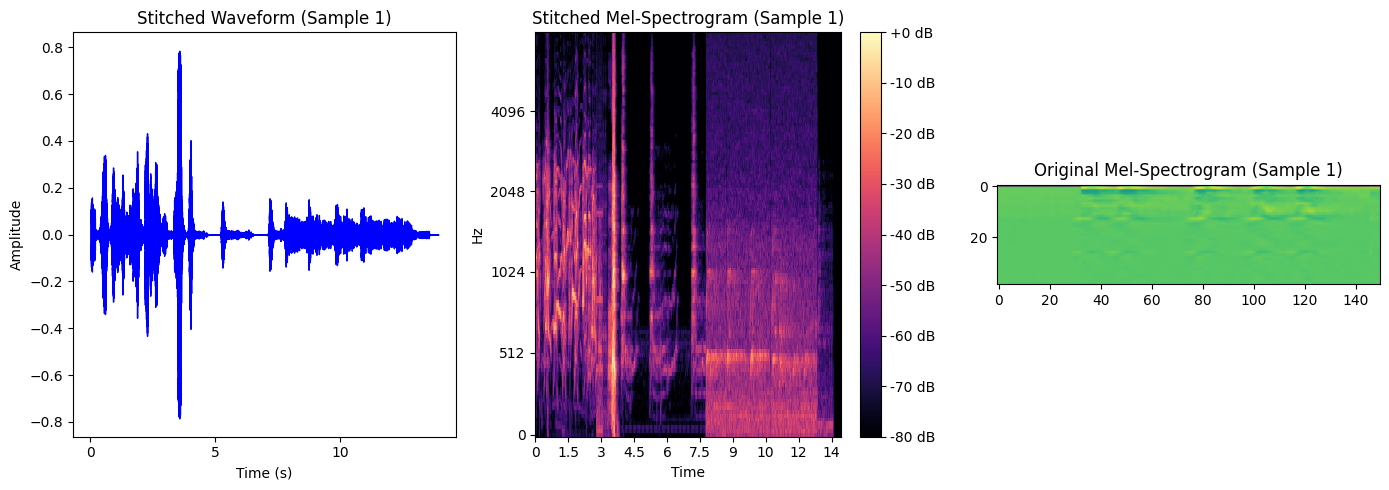

choose seed with fg: tensor(775.8726)


  0%|          | 0/150 [00:00<?, ?it/s]


Reconstructing via Patch Stitching... torch.Size([150, 2]) history


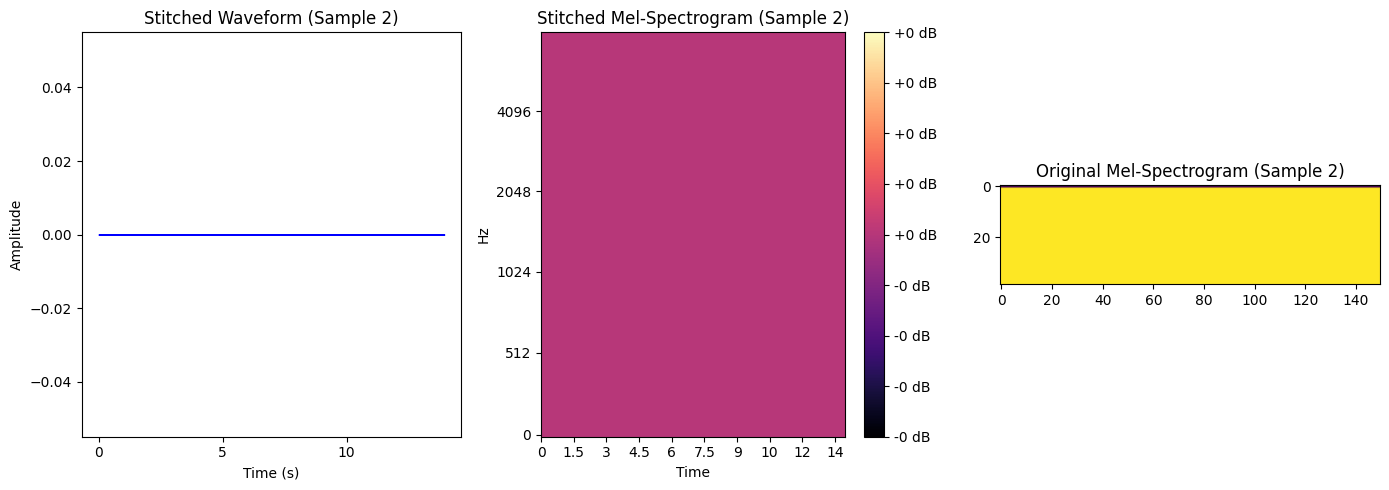

/usr/local/lib/python3.12/dist-packages/IPython/lib/display.py:174: RuntimeWarning: invalid value encountered in divide
  scaled = data / normalization_factor * 32767
/usr/local/lib/python3.12/dist-packages/IPython/lib/display.py:175: RuntimeWarning: invalid value encountered in cast
  return scaled.astype("<h").tobytes(), nchan


In [ ]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

OUT_TIME_STEPS = 150   # How many frames to synthesize (150 <- ~3.5 seconds)

for i in range(NUM_SAMPLES_TO_TEST):
    # 4. Synthesize New MFCC
    # (Using weighted=True and eps=0.1 for a bit of variation)
    out_mfcc, history_indices = synthesize_audio_mfcc(
        patches=patches,
        out_time_steps=OUT_TIME_STEPS,
        eps=0.1,
        seed_fg_min=150,
        weighted=True
    )

    # 5. Reconstruct Audio: Method 1 (Stitch)
    print(f"\nReconstructing via Patch Stitching... {history_indices.shape} history")
    audio_stitched = reconstruct_audio(
        method="stitch",
        chosen_indices=history_indices,
        source_audio=raw_audio,
        hop_length=HOP_LENGTH,
        window_t=WINDOW_T
    )

    # --- NEW: Visualization ---
    plt.figure(figsize=(14, 5))

    # Plot 1: The Waveform
    plt.subplot(1, 3, 1)
    librosa.display.waveshow(audio_stitched, sr=SR, color='blue')
    plt.title(f"Stitched Waveform (Sample {i+1})")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    # Plot 2: The Mel-Spectrogram
    plt.subplot(1, 3, 2)
    # Calculate mel-spectrogram for visualization
    S = librosa.feature.melspectrogram(y=audio_stitched, sr=SR, n_mels=128, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=SR, x_axis='time', y_axis='mel', fmax=8000, cmap='magma')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Stitched Mel-Spectrogram (Sample {i+1})")


    # Plot 2: The Mel-Spectrogram
    plt.subplot(1, 3, 3)
    # Calculate mel-spectrogram for visualization
    plt.imshow(out_mfcc.squeeze())
    plt.title(f"Original Mel-Spectrogram (Sample {i+1})")

    plt.tight_layout()
    plt.show()
    # ---------------------------

    # Save and Display Stitched
    stitch_path = OUTPUT_DIR / f"stitched_{filepath.stem}_{i}.wav"
    sf.write(stitch_path, audio_stitched, SR)
    display(HTML(f"<b>Generated Audio (Stitched):</b> Saved to {stitch_path.name}"))
    display(Audio(audio_stitched, rate=SR))

    print("="*40)

In [ ]:
print(history_indices[:, 0].unique())

tensor([24204, 24205, 24206, 24207, 24208, 24209, 24210, 24211, 24212, 24214,
        24215, 24216, 24217, 24218, 24219, 24220, 24221, 24222, 24223, 24224,
        24225, 24226, 24227, 24228, 24229, 24230, 24231, 24232, 24233, 24234,
        24235, 24236, 24237, 24238, 24239, 24240, 24241, 24242, 24243, 24244,
        24245, 24246, 25873, 25874, 25875, 25876, 25877, 25878, 25879, 25880,
        25881, 25882, 25883, 25884, 25885, 25886, 25887, 25888, 25889, 25890,
        25891, 25892, 25893, 25894, 25895, 25896, 25897, 25898, 25899, 25900,
        25901, 25902, 25903, 25904, 25905, 25906, 25907, 25908, 25909, 25910,
        25911, 25912, 25913, 25914, 25915, 25916, 25948])


In [ ]:
len(source)

33915

In [ ]:
history_indices

tensor([[8688,   69],
        [8689,   69],
        [8690,   69],
        [8691,   69],
        [8692,   69],
        [8693,   69],
        [8836,    0],
        [8836,    1],
        [8836,    2],
        [8836,    3],
        [8836,    4],
        [8836,    5],
        [8836,    6],
        [8836,    7],
        [8836,    8],
        [8836,    9],
        [8836,   10],
        [8836,   11],
        [8836,   12],
        [8836,   13],
        [8836,   14],
        [8836,   15],
        [8836,   16],
        [8836,   17],
        [8836,   18],
        [8836,   19],
        [8836,   20],
        [8836,   21],
        [8836,   22],
        [8836,   23],
        [8836,   24],
        [8836,   25],
        [8836,   26],
        [8836,   27],
        [8836,   28],
        [8836,   29],
        [8836,   30],
        [8836,   31],
        [8836,   32],
        [8836,   33],
        [8836,   34],
        [8836,   35],
        [8836,   36],
        [8836,   37],
        [8836,   38],
        [8

np.float32(0.01854534)

In [ ]:
# TODO add positional bias
#
raw_audio[44347-63//2:44347+63//2]

array([ 1.9778445e-02,  1.3956042e-02,  1.1296172e-02,  9.3053980e-03,
        9.3204193e-03,  1.3573563e-02,  2.0788323e-02,  2.8846903e-02,
        3.6747165e-02,  4.4315286e-02,  4.9238950e-02,  4.8725724e-02,
        4.5754075e-02,  4.2656317e-02,  3.6238506e-02,  2.6068289e-02,
        1.5502039e-02,  6.4329784e-03,  6.8809965e-04, -9.1533887e-04,
        1.7617361e-03,  9.2474967e-03,  1.6649837e-02,  2.3522016e-02,
        3.1286843e-02,  3.9604701e-02,  4.9534101e-02,  5.8677007e-02,
        6.4868256e-02,  6.3864164e-02,  5.6315824e-02,  4.3843471e-02,
        3.1331077e-02,  2.0636024e-02,  1.1433755e-02,  7.8455741e-03,
        6.8767732e-03,  6.8084132e-03,  9.3271788e-03,  1.5295690e-02,
        2.2956278e-02,  3.0617272e-02,  3.6472425e-02,  4.1225981e-02,
        4.5812320e-02,  4.7275487e-02,  4.6815768e-02,  4.5372732e-02,
        4.3804757e-02,  4.2098854e-02,  3.9185382e-02,  3.7756674e-02,
        3.4658119e-02,  2.8842794e-02,  2.2285659e-02,  1.5123846e-02,
      

In [ ]:
display(Audio(raw_audio[44347-5000:44347+5000], rate=SR))

# END OF PROJECT CODE

### The rest is from HW2

  0%|          | 0/16384 [00:00<?, ?it/s]

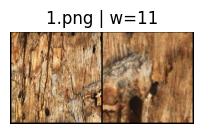

  0%|          | 0/16384 [00:00<?, ?it/s]

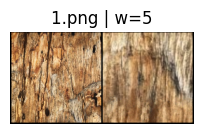

  0%|          | 0/16384 [00:00<?, ?it/s]

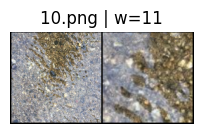

  0%|          | 0/16384 [00:00<?, ?it/s]

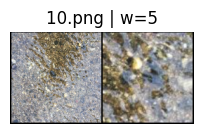

  0%|          | 0/16384 [00:00<?, ?it/s]

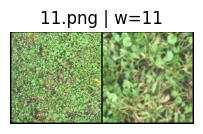

  0%|          | 0/16384 [00:00<?, ?it/s]

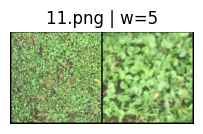

  0%|          | 0/16384 [00:00<?, ?it/s]

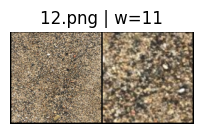

  0%|          | 0/16384 [00:00<?, ?it/s]

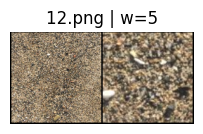

  0%|          | 0/16384 [00:00<?, ?it/s]

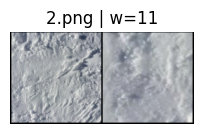

  0%|          | 0/16384 [00:00<?, ?it/s]

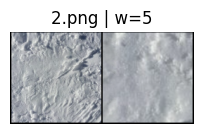

  0%|          | 0/16384 [00:00<?, ?it/s]

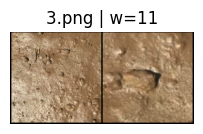

  0%|          | 0/16384 [00:00<?, ?it/s]

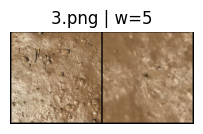

  0%|          | 0/16384 [00:00<?, ?it/s]

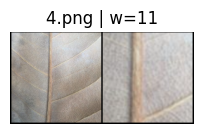

  0%|          | 0/16384 [00:00<?, ?it/s]

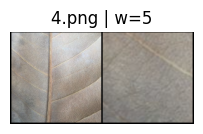

  0%|          | 0/16384 [00:00<?, ?it/s]

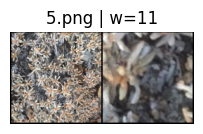

  0%|          | 0/16384 [00:00<?, ?it/s]

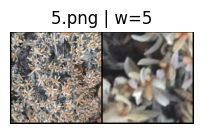

  0%|          | 0/16384 [00:00<?, ?it/s]

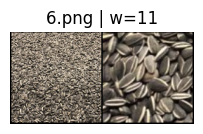

  0%|          | 0/16384 [00:00<?, ?it/s]

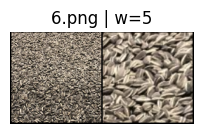

  0%|          | 0/16384 [00:00<?, ?it/s]

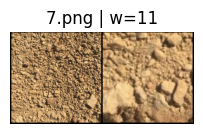

  0%|          | 0/16384 [00:00<?, ?it/s]

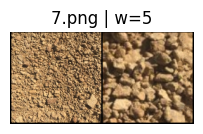

  0%|          | 0/16384 [00:00<?, ?it/s]

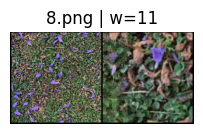

  0%|          | 0/16384 [00:00<?, ?it/s]

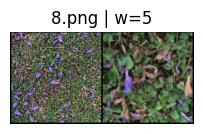

  0%|          | 0/16384 [00:00<?, ?it/s]

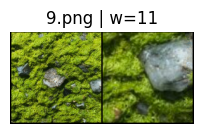

  0%|          | 0/16384 [00:00<?, ?it/s]

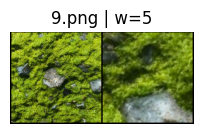

In [ ]:
from torch._C import NoneType
# ---- Part 1 demo (will run after you implement the TODOs) ----
OUT_H, OUT_W = 128, 128
WINDOWS = [11, 5]          # TODO (tuning): try e.g. [5, 11]
EPS = 0.02            # TODO (tuning): try e.g. 0.02, 0.05, 0.1
MAX_PATCHES = None     # e.g., 50000 to cap candidates for speed/memory
RESIZE_SRC = None       # resize textures for consistent runtime
NEIGHBORHOOD = 8      # 4 or 8
VERBOSE = True

for path in texture_files[::]:
    #print(path)
    src = load_texture_as_tensor(path, resize=RESIZE_SRC).to(device)
    for w in WINDOWS:
        patches = extract_patches_from_image(src, window=w, max_patches=MAX_PATCHES, device=device)
        out = efros_leung_synthesize_from_patch_pool(
            patches=patches,
            out_h=OUT_H, out_w=OUT_W,
            eps=EPS,
            neighborhood=NEIGHBORHOOD,
            seed_fg_min=0.2,
            border=0,
            weighted=True,
            h_mult=0.1,
            verbose=VERBOSE,
            max_steps=None
        )
        show_grid([src.cpu(), out], nrow=2, resize_to=(OUT_H, OUT_W), title=f"{path.name} | w={w}")


## (Required) Tuning / Ablations

This assignment is *not* meant to be one-run-and-done. You should **tune** the key hyperparameters and report what changes.

Minimum tuning expectations (include in the report):
- **Part 1 (textures):** tune `window` size and `eps` (candidate-set threshold).
- **Part 2 (MNIST):** tune `window` size and `eps` (and optionally `seed_fg_min`, `border`, `weighted`).
- **Part 3 (PixelRNN):** tune at least one of: `hidden_dim`, `num_layers`, `dropout`, `lr`, `temperature`.

Below is an optional helper scaffold to run small sweeps. Fill in the TODOs if you want
a clean tuning workflow (recommended).


In [ ]:
from IPython.utils.sysinfo import pprint
from itertools import product

def tune_efros_grid(
    patch_pool_builder,
    window_list,
    eps_list,
    out_h: int,
    out_w: int,
    trials: int = 1,
    synth_kwargs: dict | None = None,
    max_steps: int | None = None,
):
    """
    Grid-search over (window, eps) for Efros–Leung.

    Args:
      patch_pool_builder: function(window:int) -> patches (N,C,window,window) on `device`
      window_list: list of odd window sizes to try, e.g. [5, 11]
      eps_list: list of eps to try, e.g. [0.02, 0.05, 0.1]
      trials: number of random restarts per config (average the score)
      synth_kwargs: extra kwargs passed into efros_leung_synthesize_from_patch_pool
      max_steps: optional cap on fill steps (useful for fast tuning)

    Returns:
      best_cfg: dict with keys {"window", "eps", "score"}
      results: list of dicts (one per config), sorted by ascending score

    TODO:
      - For each (window, eps):
          * build patch pool
          * run efros_leung_synthesize_from_patch_pool(..., return_stats=True, max_steps=max_steps)
          * use stats["avg_dmin"] as a simple score (lower is better)
          * average the score over `trials`
      - Return the best config and a sorted result list.
    """
    runs = []
    for window in tqdm(window_list):
        patches = patch_pool_builder(window)
        for eps in tqdm(eps_list):
            dmin = []
            for trial in range(trials):
                (out, stats) = efros_leung_synthesize_from_patch_pool(
                    patches=patches,
                    eps=eps,
                    max_steps=max_steps,
                    out_h=out_h, out_w=out_w,
                    return_stats=True,
                    **synth_kwargs
                )
                dmin.append(stats["avg_dmin"])
            runs.append(
              (
                  np.array(dmin).mean(),
                  { # config
                    'window': window,
                    'eps' : eps,
                    'synth_kwargs' : synth_kwargs
                  }
              )
            )
    runs = sorted(runs, key=lambda x: x[0])
    return runs


In [ ]:
src = load_texture_as_tensor(texture_files[-1], resize=RESIZE_SRC).to(device)
patch_pool_builder = lambda w: extract_patches_from_image(src, window=w, max_patches=MAX_PATCHES, device=device)

runs = tune_efros_grid(
    patch_pool_builder,
    window_list = [3, 5, 7, 9, 11, 13, 15, 17],
    eps_list = [0.01, 0.1, 0.002],
    out_h=OUT_H,
    out_w=OUT_W,
    trials = 2,
    synth_kwargs = dict(weighted=True, h_mult=0.1, seed_fg_min=0.2),
    max_steps = None,
)
pprint.pprint(runs)


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

[(np.float64(0.0),
  {'eps': 0.01,
   'synth_kwargs': {'h_mult': 0.1, 'seed_fg_min': 0.2, 'weighted': True},
   'window': 3}),
 (np.float64(0.0),
  {'eps': 0.1,
   'synth_kwargs': {'h_mult': 0.1, 'seed_fg_min': 0.2, 'weighted': True},
   'window': 3}),
 (np.float64(0.0),
  {'eps': 0.01,
   'synth_kwargs': {'h_mult': 0.1, 'seed_fg_min': 0.2, 'weighted': True},
   'window': 5}),
 (np.float64(0.0),
  {'eps': 0.1,
   'synth_kwargs': {'h_mult': 0.1, 'seed_fg_min': 0.2, 'weighted': True},
   'window': 5}),
 (np.float64(0.0),
  {'eps': 0.01,
   'synth_kwargs': {'h_mult': 0.1, 'seed_fg_min': 0.2, 'weighted': True},
   'window': 7}),
 (np.float64(0.0),
  {'eps': 0.1,
   'synth_kwargs': {'h_mult': 0.1, 'seed_fg_min': 0.2, 'weighted': True},
   'window': 7}),
 (np.float64(0.0),
  {'eps': 0.01,
   'synth_kwargs': {'h_mult': 0.1, 'seed_fg_min': 0.2, 'weighted': True},
   'window': 9}),
 (np.float64(0.0),
  {'eps': 0.1,
   'synth_kwargs': {'h_mult': 0.1, 'seed_fg_min': 0.2, 'weighted': True},
   'wi

## Part 2 — MNIST (binarized)

MNIST is downloaded automatically.


  0%|          | 0.00/9.91M [00:00<?, ?B/s]
  1%|          | 98.3k/9.91M [00:00<00:11, 818kB/s]
  3%|▎         | 328k/9.91M [00:00<00:06, 1.44MB/s]
 13%|█▎        | 1.31M/9.91M [00:00<00:01, 4.45MB/s]
100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]

100%|██████████| 28.9k/28.9k [00:00<00:00, 496kB/s]

  0%|          | 0.00/1.65M [00:00<?, ?B/s]
  4%|▍         | 65.5k/1.65M [00:00<00:02, 549kB/s]
 16%|█▌        | 262k/1.65M [00:00<00:01, 1.18MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


MNIST: torch.Size([60000, 1, 28, 28]) torch.Size([60000]) unique: tensor([0., 1.])
foreground ratio (mean pixel): 0.1322583109140396


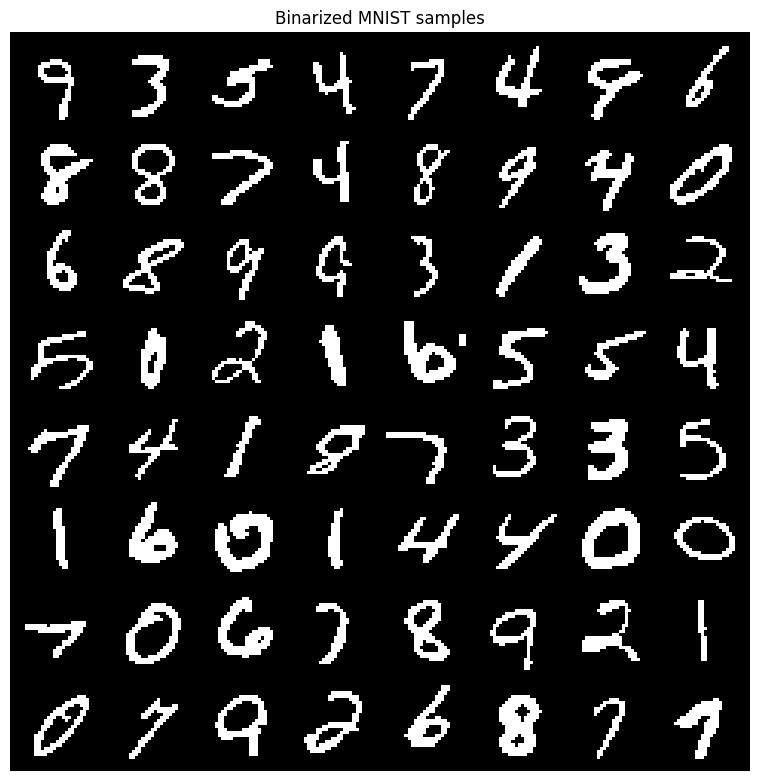

In [ ]:
def load_binarized_mnist(threshold: float = 0.5):
    transform = T.Compose([T.ToTensor()])
    train_set = torchvision.datasets.MNIST(root="/content/data", train=True, download=True, transform=transform)
    test_set  = torchvision.datasets.MNIST(root="/content/data", train=False, download=True, transform=transform)

    x_train = train_set.data.unsqueeze(1).float() / 255.0
    y_train = train_set.targets
    x_test  = test_set.data.unsqueeze(1).float() / 255.0
    y_test  = test_set.targets

    x_train = (x_train > threshold).float()
    x_test  = (x_test  > threshold).float()
    return x_train, y_train, x_test, y_test

x_train, y_train, x_test, y_test = load_binarized_mnist(threshold=0.5)
print("MNIST:", x_train.shape, y_train.shape, "unique:", torch.unique(x_train))
print("foreground ratio (mean pixel):", float(x_train.mean().item()))

idx = torch.randperm(x_train.shape[0])[:64]
show_grid([x_train[i,0] for i in idx], nrow=8, title="Binarized MNIST samples", cmap="gray")


patch_pool: torch.Size([50000, 1, 11, 11])


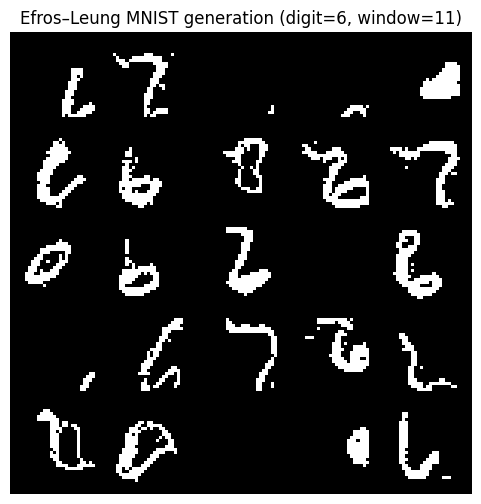

In [ ]:
def extract_patches_from_mnist_batch(
    imgs: torch.Tensor,  # (B,1,28,28) in {0,1}
    window: int,
    max_patches: int,
    device: torch.device = device,
) -> torch.Tensor:
    """Return patches: (N,1,window,window) sampled from the batch."""
    assert imgs.ndim == 4 and imgs.shape[1] == 1
    unfold = torch.nn.Unfold(kernel_size=window, padding=0, stride=1)
    patches = unfold(imgs)  # (B, win*win, L)
    B, D, L = patches.shape
    patches = patches.transpose(1, 2).reshape(B * L, 1, window, window)
    if patches.shape[0] > max_patches:
        idx = torch.randperm(patches.shape[0])[:max_patches]
        patches = patches[idx]
    return patches.to(device)

# ---- Part 2 demo (will run after you implement the TODOs) ----
# TODO (tuning): try different digits and hyperparameters; expect *stroke-like* outputs, not perfect digits.
digit = 6 # Select Your Number
window = 11              # TODO (tuning): e.g. 5, 7, 9
num_source_images = 60_000   # TODO (tuning): more sources -> more variety, slower patch pool build
max_patches = 50_000        # TODO (tuning): larger -> better coverage, slower matching

# Optional knobs (not required for correctness)
USE_MNIST_HEURISTICS = True  # set True to try a few stability tweaks on MNIST

src_imgs = x_train[y_train == digit]
sel = torch.randperm(src_imgs.shape[0])[:num_source_images]
src_batch = src_imgs[sel].to(device)

patch_pool = extract_patches_from_mnist_batch(src_batch, window=window, max_patches=max_patches, device=device)
print("patch_pool:", patch_pool.shape)

# Core Efros–Leung parameters
eps = 0.01                # TODO (tuning): smaller -> stricter matching, larger -> more randomness
neighborhood = 8          # TODO

# Heuristic parameters (off by default)
seed_fg_min = 0
border = 0
weighted = False
h_mult = 0.3
if USE_MNIST_HEURISTICS:
    seed_fg_min = 4
    border = 2
    weighted = True
    h_mult = 0.25

n_gen = 25
samples = []
for _ in range(n_gen):
    gen = efros_leung_synthesize_from_patch_pool(
        patches=patch_pool, out_h=28, out_w=28,
        eps=eps, neighborhood=neighborhood,
        seed_fg_min=seed_fg_min, border=border,
        weighted=weighted, h_mult=h_mult,
        verbose=False
    )
    samples.append(gen[0])

show_grid(samples, nrow=5, title=f"Efros–Leung MNIST generation (digit={digit}, window={window})", cmap="gray")


In [ ]:
# tuning search

patch_pool_builder_mnist = lambda w: extract_patches_from_mnist_batch(src_batch, window=w, max_patches=10_000, device=device)

runs = tune_efros_grid(
    patch_pool_builder_mnist,
    window_list = [3, 5, 7, 9, 11, 13, 15, 17],
    eps_list = [0.01, 0.1, 0.002],
    out_h=OUT_H,
    out_w=OUT_W,
    trials = 2,
    synth_kwargs = dict(weighted=True, h_mult=0.25, border=2, seed_fg_min=4),
    max_steps = 1000,
)
pprint.pprint(runs)

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

[(np.float64(0.0),
  {'eps': 0.01,
   'synth_kwargs': {'border': 2,
                    'h_mult': 0.25,
                    'seed_fg_min': 4,
                    'weighted': True},
   'window': 3}),
 (np.float64(0.0),
  {'eps': 0.1,
   'synth_kwargs': {'border': 2,
                    'h_mult': 0.25,
                    'seed_fg_min': 4,
                    'weighted': True},
   'window': 3}),
 (np.float64(0.0),
  {'eps': 0.002,
   'synth_kwargs': {'border': 2,
                    'h_mult': 0.25,
                    'seed_fg_min': 4,
                    'weighted': True},
   'window': 3}),
 (np.float64(0.0),
  {'eps': 0.01,
   'synth_kwargs': {'border': 2,
                    'h_mult': 0.25,
                    'seed_fg_min': 4,
                    'weighted': True},
   'window': 5}),
 (np.float64(0.0),
  {'eps': 0.1,
   'synth_kwargs': {'border': 2,
                    'h_mult': 0.25,
                    'seed_fg_min': 4,
                    'weighted': True},
   'window': 5}),
 (np.f

## Part 3 — PixelRNN (binarized MNIST)

Implement a raster-scan autoregressive RNN.

In [ ]:
def make_pixel_sequences(x: torch.Tensor):
    """
    x: (B,1,28,28) in {0,1}
    Returns:
      x_in: (B,784) tokens in {0,1,2} where 2 is START
      y:    (B,784) float targets in {0,1}
    """
    B = x.shape[0]
    pixels = x.view(B, -1).long()
    start = torch.full((B, 1), 2, dtype=torch.long)
    x_in = torch.cat([start, pixels[:, :-1]], dim=1)
    y = pixels.float()
    return x_in, y

def make_dataloaders(x_train, x_test, batch_size=128, train_subset=None):
    if train_subset is not None and train_subset < x_train.shape[0]:
        idx = torch.randperm(x_train.shape[0])[:train_subset]
        x_tr = x_train[idx]
    else:
        x_tr = x_train

    x_in_tr, y_tr = make_pixel_sequences(x_tr)
    x_in_te, y_te = make_pixel_sequences(x_test)

    train_ds = TensorDataset(x_in_tr, y_tr)
    test_ds = TensorDataset(x_in_te, y_te)

    num_workers = 2 if device.type == "cuda" else 0
    pin_memory = (device.type == "cuda")

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers,
                              pin_memory=pin_memory, persistent_workers=(num_workers > 0))
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers,
                             pin_memory=pin_memory, persistent_workers=(num_workers > 0))
    return train_loader, test_loader


In [ ]:
class PixelRNN(nn.Module):
    def __init__(self, emb_dim=32, hidden_dim=256, num_layers=2, dropout=0.1):
        super().__init__()
        # Tokens: 0, 1, START. (Use START = 2)
        # Positions: row index in [0..27], col index in [0..27]
        #
        # TODO:
        #   - token embedding: nn.Embedding(3, emb_dim)
        #   - row/col embeddings: nn.Embedding(28, emb_dim) each
        #   - LSTM: nn.LSTM(emb_dim, hidden_dim, num_layers, batch_first=True, ...)
        #   - output head: nn.Linear(hidden_dim, 1) to produce logits for x_t
        #
        # IMPORTANT: this must be a *causal* model. Do NOT peek at future pixels.
        self.emb = nn.Embedding(3, emb_dim)
        self.row_emb = nn.Embedding(28, emb_dim)
        self.col_emb = nn.Embedding(28, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers, batch_first=True, bidirectional=False)
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dim, 1)


        # Optional convenience (recommended): precompute raster positions for length 784 (T=28*28)
        t = torch.arange(28 * 28)
        self.register_buffer("pos_row", (t // 28).long(), persistent=False)
        self.register_buffer("pos_col", (t % 28).long(), persistent=False)

        self.use_rope = False

        # Remove this line after implementing the model.
        # raise NotImplementedError

    def apply_pos_emb(self, emb, pos_row, pos_col):
        row_emb = self.row_emb(pos_row)
        col_emb = self.col_emb(pos_col)
        if not self.use_rope:
            return emb + row_emb + col_emb
        else:
            raise NotImplementedError()


    def forward(self, x_in: torch.Tensor):
        """
        x_in: (B,784) tokens in {0,1,2}, where 2 denotes START at t=0 (teacher-forcing input).
        Return:
          logits: (B,784) where logits[:,t] parameterizes p(x_t=1 | x_<t)

        Notes:
          - `make_pixel_sequences()` already inserts the START token and shifts the sequence.
          - Add row/col positional embeddings based on t -> (t//28, t%28).
        """
        # input 0 - t (actually t-1) ( shifted, so 0 is already START )
        emb = self.apply_pos_emb(
            self.emb(x_in[:, :]),
            self.pos_row[:],
            self.pos_col[:]
        )
        # lstm is causal and iterates efficiently internally, using teacher forcing
        logit, (hn, cn) = self.lstm(emb)
        logit = self.dropout(logit)
        logit = self.out(logit).squeeze()
        return logit

    @torch.no_grad()
    def sample(self, n: int, temperature: float = 1.0):
        """
        Ancestral sampling in raster order.
        Return: samples (n,1,28,28) in {0,1}.

        TODO:
          - Start with prev token = START for all n samples.
          - For t=0..783:
              - embed prev token (+ positional embedding for position t)
              - run 1-step LSTM using cached hidden state
              - map hidden -> logit -> prob
              - sample next pixel using Bernoulli(prob)
              - set prev = sampled pixel token (0/1)
        """
        # Here we need to iterate ourselves
        hn = torch.zeros(self.lstm.num_layers, n, self.lstm.hidden_size).to(self.pos_row.device)
        cn = torch.zeros(self.lstm.num_layers, n, self.lstm.hidden_size).to(self.pos_row.device)

        # Hardcoded dims :)
        out = torch.zeros(n, 784, dtype=torch.float32, device=self.pos_row.device)
        current_tok = torch.full((n,), 2, device=self.pos_row.device) # START=2

        for t in range(0, 784):
            # initialize embeddings
            # We feed one token to the model at each iteration
            # RNNs maintain state internally, they don't need the whole sequence until the present to generate
            emb = self.apply_pos_emb(
                self.emb(current_tok),
                self.pos_row[t],
                self.pos_col[t]
            ).view(n, 1, self.emb.embedding_dim)

            # calculate logits->prob->sample
            logit, (hn, cn) = self.lstm(emb, (hn, cn))
            logit = self.out(logit.squeeze()).squeeze()
            prob = F.sigmoid(logit / temperature)
            # temperature is applied before sigmoid to ensure valid prob distribution
            current_tok = torch.bernoulli(prob).long()
            out[:, t] = current_tok

        return out.reshape(n, 1, 28, 28).float() # reshape and float in [0.0, 1.0] range



In [ ]:
def evaluate_nll_per_pixel(model: nn.Module, loader: DataLoader):
    model.eval()
    total = 0.0
    count = 0
    bce = nn.BCEWithLogitsLoss(reduction="sum")
    with torch.no_grad():
        for x_in, y in loader:
            x_in = x_in.to(device)
            y = y.to(device)
            logits = model(x_in)
            loss = bce(logits, y)
            total += float(loss.item())
            count += int(y.numel())
    return total / count

def train_pixelrnn(model: nn.Module, train_loader: DataLoader, test_loader: DataLoader, epochs=10, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCEWithLogitsLoss(reduction="mean")
    history = {"train_loss": [], "test_nll": []}

    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        n_batches = 0
        pbar = tqdm(train_loader, desc=f"epoch {ep}/{epochs}")
        for x_in, y in pbar:
            x_in = x_in.to(device)
            y = y.to(device)

            opt.zero_grad(set_to_none=True)
            logits = model(x_in)
            loss = bce(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            running += float(loss.item())
            n_batches += 1
            pbar.set_postfix(loss=running / n_batches)

        train_loss = running / max(1, n_batches)
        test_nll = evaluate_nll_per_pixel(model, test_loader)
        history["train_loss"].append(train_loss)
        history["test_nll"].append(test_nll)
        print(f"epoch {ep}: train_loss={train_loss:.4f} | test_nll/pixel={test_nll:.4f}")

    return history


### PixelRNN tuning helper (optional but recommended)

A simple hyperparameter sweep runner. Use a small `train_subset` and few epochs so you can iterate quickly.
Then train your best configuration longer for the final results.


In [ ]:
def sweep_pixelrnn_configs(
    x_train: torch.Tensor,
    x_test: torch.Tensor,
    configs: list[dict],
    train_subset: int = 10000,
    epochs: int = 2,
    batch_size: int = 128,
):
    """
    Sweep a list of PixelRNN configs.

    Each entry in `configs` is a dict like:
      {
        "model_kwargs": {"emb_dim": 32, "hidden_dim": 256, "num_layers": 2, "dropout": 0.1},
        "lr": 1e-3,
      }

    TODO:
      - For each config:
          * make loaders with make_dataloaders(..., train_subset=train_subset)
          * instantiate PixelRNN(**model_kwargs)
          * train with train_pixelrnn(..., epochs=epochs, lr=lr)
          * evaluate test_nll_per_pixel via evaluate_nll_per_pixel
      - Return a list of results sorted by test_nll (ascending)
    """
    results = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Starting sweep on device: {device}")

    for i, config in enumerate(configs):
        model_kwargs = config.get("model_kwargs", {})
        lr = config.get("lr", 1e-3)

        print(f"\n--- Running Config {i+1}/{len(configs)} ---")
        print(f"Args: {model_kwargs}, LR: {lr}")

        # 1. Create DataLoaders
        train_loader, test_loader = make_dataloaders(
            x_train, x_test, batch_size=batch_size, train_subset=train_subset
        )

        # 2. Instantiate Model
        model = PixelRNN(**model_kwargs).to(device)

        # 3. Train
        train_pixelrnn(model, train_loader, test_loader, epochs=epochs, lr=lr)

        # 4. Evaluate
        test_nll = evaluate_nll_per_pixel(model, test_loader)

        print(f"Results for Config {i+1}: Test NLL = {test_nll:.4f}")

        # Store results
        results.append({
            "config": config,
            "test_nll": test_nll
        })

    # 5. Sort by test_nll (ascending: lower NLL is better)
    results.sort(key=lambda x: x["test_nll"])

    return results
sweep_pixelrnn_configs(
    x_train, x_test,
    [
        { "model_kwargs": {"emb_dim": 32, "hidden_dim": 256, "num_layers": 2, "dropout": 0.1}, "lr": 1e-3,},
        { "model_kwargs": {"emb_dim": 64, "hidden_dim": 256, "num_layers": 4, "dropout": 0.2}, "lr": 1e-3,},
        { "model_kwargs": {"emb_dim": 32, "hidden_dim": 256, "num_layers": 2, "dropout": 0.1}, "lr": 1e-2,},
        { "model_kwargs": {"emb_dim": 64, "hidden_dim": 256, "num_layers": 2, "dropout": 0.1}, "lr": 1e-3,},
    ],
)

Starting sweep on device: cuda

--- Running Config 1/4 ---
Args: {'emb_dim': 32, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.1}, LR: 0.001


epoch 1/2:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 1: train_loss=0.2474 | test_nll/pixel=0.1643


epoch 2/2:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 2: train_loss=0.1455 | test_nll/pixel=0.1285
Results for Config 1: Test NLL = 0.1285

--- Running Config 2/4 ---
Args: {'emb_dim': 64, 'hidden_dim': 256, 'num_layers': 4, 'dropout': 0.2}, LR: 0.001


...

epoch 1/2:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 1: train_loss=0.2285 | test_nll/pixel=0.1603


epoch 2/2:   0%|          | 0/79 [00:00<?, ?it/s]

epoch 2: train_loss=0.1449 | test_nll/pixel=0.1301
Results for Config 4: Test NLL = 0.1301


[{'config': {'model_kwargs': {'emb_dim': 32,
    'hidden_dim': 256,
    'num_layers': 2,
    'dropout': 0.1},
   'lr': 0.01},
  'test_nll': 0.1113916849408831},
 {'config': {'model_kwargs': {'emb_dim': 64,
    'hidden_dim': 256,
    'num_layers': 4,
    'dropout': 0.2},
   'lr': 0.001},
  'test_nll': 0.12834877037515446},
 {'config': {'model_kwargs': {'emb_dim': 32,
    'hidden_dim': 256,
    'num_layers': 2,
    'dropout': 0.1},
   'lr': 0.001},
  'test_nll': 0.12850224417861628},
 {'config': {'model_kwargs': {'emb_dim': 64,
    'hidden_dim': 256,
    'num_layers': 2,
    'dropout': 0.1},
   'lr': 0.001},
  'test_nll': 0.13007626713344028}]

epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

epoch 1: train_loss=0.1208 | test_nll/pixel=0.0855


epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

epoch 2: train_loss=0.0828 | test_nll/pixel=0.0794


epoch 3/10:   0%|          | 0/469 [00:00<?, ?it/s]

...

epoch 8: train_loss=0.0740 | test_nll/pixel=0.0744


epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

epoch 9: train_loss=0.0737 | test_nll/pixel=0.0742


epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

epoch 10: train_loss=0.0734 | test_nll/pixel=0.0745


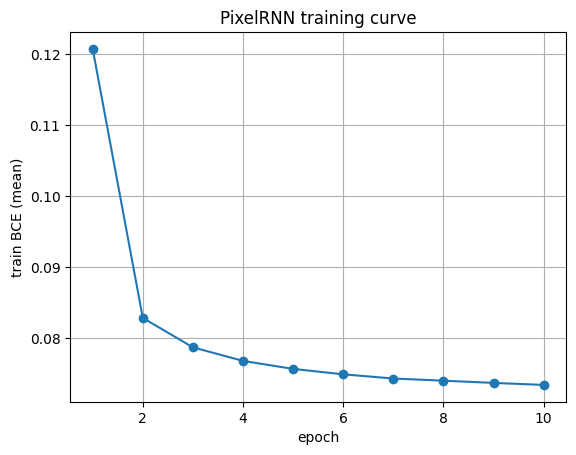

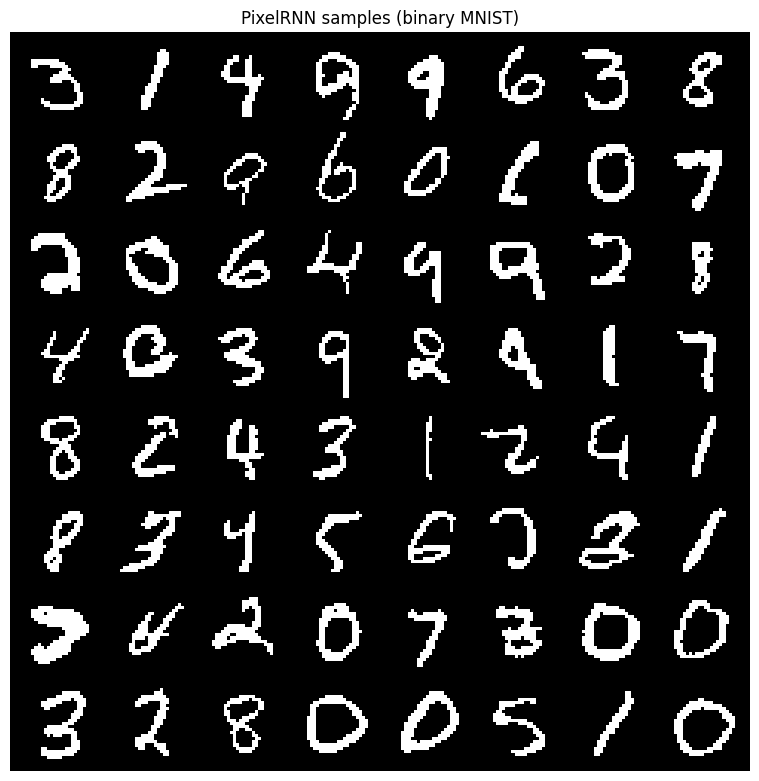

In [ ]:
# ---- Part 3 demo (will run after you implement PixelRNN) ----
# TODO (tuning): change model size and training hyperparameters; report test NLL/pixel + sample quality.
BATCH_SIZE = 128
TRAIN_SUBSET = None   # e.g., 10000 for quick debugging / sweeps
EPOCHS = 10
LR =  1e-2 # from hyperparam search above

MODEL_KWARGS = dict(
    emb_dim= 32,        #  (tuning)
    hidden_dim= 256,    #  (tuning)
    num_layers= 2,      #  (tuning)
    dropout=0.1,
)

TEMPERATURE = 1.0     # TODO (tuning)e.g.,0.7～1.3

train_loader, test_loader = make_dataloaders(
    x_train, x_test,
    batch_size=BATCH_SIZE,
    train_subset=TRAIN_SUBSET,
)

model = PixelRNN(**MODEL_KWARGS).to(device)
history = train_pixelrnn(model, train_loader, test_loader, epochs=EPOCHS, lr=LR)

plt.figure()
plt.plot(range(1, len(history["train_loss"]) + 1), history["train_loss"], marker="o")
plt.xlabel("epoch")
plt.ylabel("train BCE (mean)")
plt.title("PixelRNN training curve")
plt.grid(True)
plt.show()

samples = model.sample(n=64, temperature=TEMPERATURE)
show_grid([samples[i, 0] for i in range(64)], nrow=8, title="PixelRNN samples (binary MNIST)", cmap="gray")


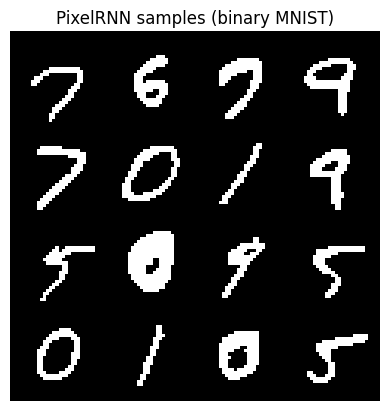

In [ ]:
TEMPERATURE = 0.7
samples = PixelRNN.sample(model, n=64, temperature=TEMPERATURE)
show_grid([samples[i, 0] for i in range(16)], nrow=4, title="PixelRNN samples (binary MNIST)", cmap="gray")

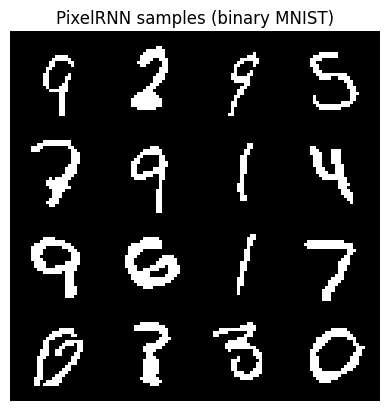

In [ ]:
TEMPERATURE = 1.0
samples = PixelRNN.sample(model, n=64, temperature=TEMPERATURE)
show_grid([samples[i, 0] for i in range(16)], nrow=4, title="PixelRNN samples (binary MNIST)", cmap="gray")

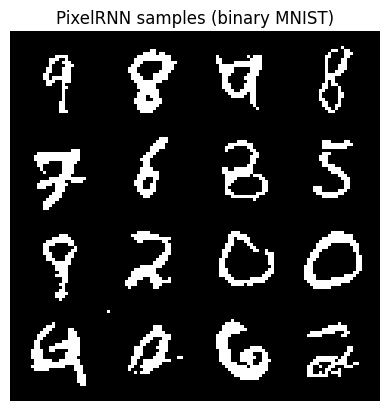

In [ ]:
TEMPERATURE = 1.3
samples = PixelRNN.sample(model, n=64, temperature=TEMPERATURE)
show_grid([samples[i, 0] for i in range(16)], nrow=4, title="PixelRNN samples (binary MNIST)", cmap="gray")

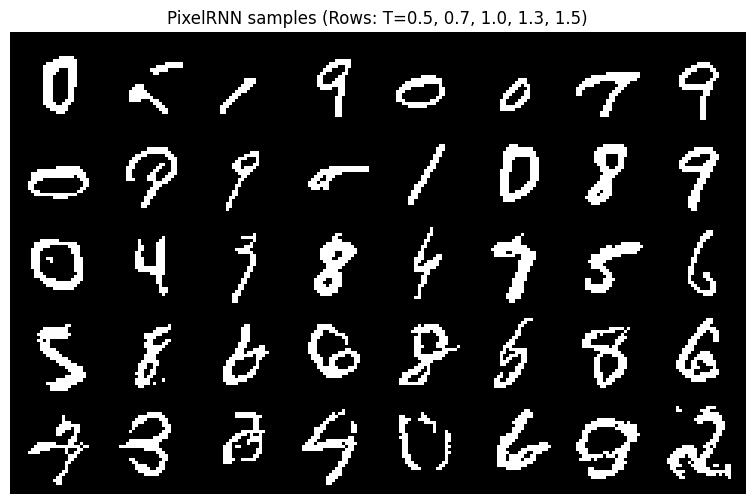

In [ ]:
# Define the 4 temperature levels you want to visualize
temperatures = [0.5, 0.7, 1.0, 1.3, 1.5]
all_samples = []

for temp in temperatures:
    # Sample 4 images for the current temperature
    samples = PixelRNN.sample(model, n=8, temperature=temp)

    # Extract the images and add them to our list
    # Assuming samples is a tensor of shape (4, 1, H, W)
    for i in range(8):
        all_samples.append(samples[i, 0])

# Display the 16 images (4 rows, where each row represents a different temperature)
show_grid(
    all_samples,
    nrow=8,
    title=f"PixelRNN samples (Rows: T={', '.join([str(round(x, 2)) for x in temperatures])})",
    cmap="gray"
)

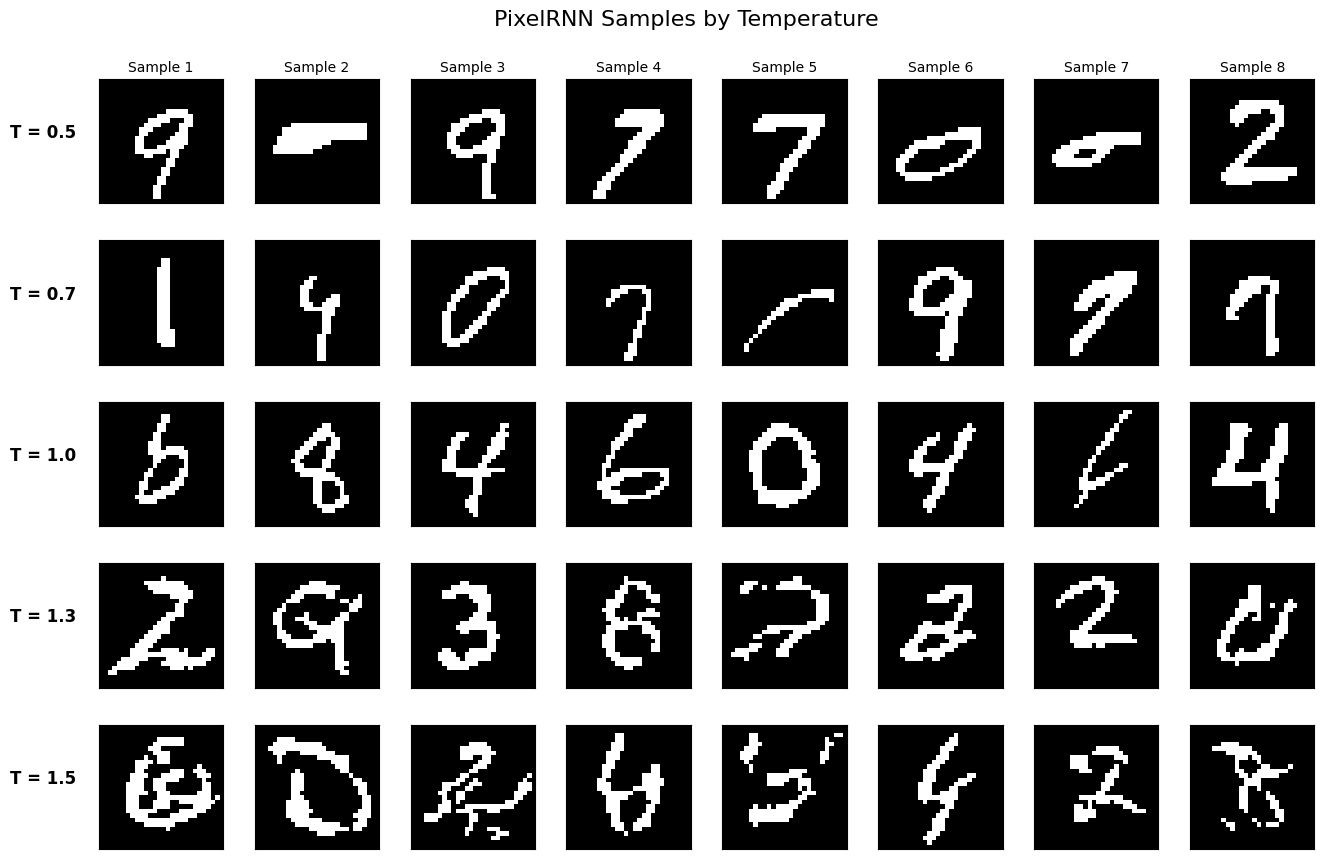

In [ ]:
import matplotlib.pyplot as plt
import torch

# Configuration
temperatures = [0.5, 0.7, 1.0, 1.3, 1.5]
samples_per_temp = 8

# Setup the figure
fig, axes = plt.subplots(
    len(temperatures),
    samples_per_temp,
    figsize=(samples_per_temp * 2, len(temperatures) * 2),
    gridspec_kw={'wspace': 0.05, 'hspace': 0.3} # Tight horizontal, room for row titles
)

for i, temp in enumerate(temperatures):
    # Generate samples for this temperature
    # Assuming samples shape is (samples_per_temp, 1, H, W)
    samples = PixelRNN.sample(model, n=samples_per_temp, temperature=temp)
    samples = samples.detach().cpu()

    for j in range(samples_per_temp):
        ax = axes[i, j]

        # Display the image
        # Using [j, 0] to grab the first channel of the j-th sample
        ax.imshow(samples[j, 0], cmap='gray', interpolation='nearest')

        # Remove axis ticks
        ax.set_xticks([])
        ax.set_yticks([])

        # Add a Row Label for the first image in each row
        if j == 0:
            ax.set_ylabel(f"T = {temp}", fontsize=12, fontweight='bold', rotation=0, labelpad=40)

        # Optional: Add column labels for the first row
        if i == 0:
            ax.set_title(f"Sample {j+1}", fontsize=10)

plt.suptitle("PixelRNN Samples by Temperature", fontsize=16, y=0.95)
plt.show()